In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ab33notu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:08<00:00, 19.7MB/s]


# Bean Leaf Lesions Classification

In [2]:
# =========================
# IMPORT REQUIRED LIBRARIES
# =========================

import torch
# Main PyTorch library for tensors and deep learning

from torch import nn
# Provides neural network modules like layers, loss functions

from torch.optim import Adam
# Adam optimizer for training the model

from torchvision import transforms
# Used for image transformations (resize, normalize, etc.)

from torch.utils.data import DataLoader, Dataset
# DataLoader → batching & shuffling
# Dataset → custom dataset creation

from torchvision import models
# Pre-trained models like ResNet, VGG, etc.

from sklearn.preprocessing import LabelEncoder
# Converts categorical labels (e.g., "cat", "dog") into numbers

import matplotlib.pyplot as plt
# For plotting graphs (loss, accuracy, images)

from PIL import Image
# For image loading and processing

import pandas as pd
# For handling structured data (CSV, tables)

import numpy as np
# Numerical operations (arrays, matrices)

import os
# For file and directory handling


# =========================
# DEVICE CONFIGURATION
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
# If GPU is available → use "cuda"
# Otherwise → fallback to CPU

In [3]:
# =========================
# LOAD DATASET (CSV FILES)
# =========================

train_df = pd.read_csv("/content/bean-leaf-lesions-classification/train.csv")
# Reads the training dataset from CSV file into a pandas DataFrame

val_df = pd.read_csv("/content/bean-leaf-lesions-classification/val.csv")
# Reads the validation dataset from CSV file into a pandas DataFrame


# =========================
# PREVIEW DATA
# =========================

train_df.head()
# Displays the first 5 rows of the training dataset
# Useful to understand structure (columns, labels, file paths, etc.)

,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [4]:
print(train_df.shape)
print(val_df.shape)
# Prints the dimensions of the training and validation datasets

(1034, 2)
(133, 2)


In [5]:
print(train_df["category"].value_counts())


category
2    348
1    345
0    341
Name: count, dtype: int64


In [6]:
# =========================
# IMAGE TRANSFORMATIONS
# =========================

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    # Resizes all images to 128x128 pixels
    # Ensures uniform input size for the model

    transforms.ToTensor(),
    # Converts image (PIL or numpy) → PyTorch tensor
    # Also scales pixel values from [0, 255] → [0, 1]

    transforms.ConvertImageDtype(torch.float),
    # Converts tensor datatype to float (float32)
    # Required for most neural network computations
])

In [10]:
# =========================
# CUSTOM DATASET CLASS
# =========================

class CustomImageDataset(Dataset):

    def __init__(self, dataframe, transform):
        # Constructor → called when dataset object is created

        self.dataframe = dataframe
        # Stores the dataframe (contains image paths + labels)

        self.transform = transform
        # Stores transformation pipeline (resize, tensor, etc.)

        self.labels = torch.tensor(dataframe["category"]).to(device)
        # Converts label column into tensor and moves it to device (CPU/GPU)


    def __len__(self):
        # Returns total number of samples in dataset
        return self.dataframe.shape[0]


    def __getitem__(self, idx):
        # Fetches one data sample (image + label) using index

        img_path = self.dataframe.iloc[idx, 0]
        # Gets image path from dataframe (assuming column 0 = image path)

        label = self.labels[idx]
        # Gets corresponding label

        full_path = os.path.join("/content/bean-leaf-lesions-classification", img_path)
        image = Image.open(full_path).convert("RGB")
        # Opens image using PIL

        if self.transform:
            image = self.transform(image).to(device)
            # Applies transformations (resize, tensor conversion)
            # Divides by 255 → normalizes pixel values further (optional)
            # Moves image tensor to device (CPU/GPU)

        return image, label
        # Returns tuple → (input image, target label)

In [11]:
# =========================
# CREATE DATASET OBJECTS
# =========================

train_dataset = CustomImageDataset(
    dataframe=train_df,
    transform=transform
)
# Creates training dataset object
# Uses train_df (training data) + transformation pipeline


val_dataset = CustomImageDataset(
    dataframe=val_df,
    transform=transform
)
# Creates validation dataset object
# Uses val_df (validation data) + same transformations

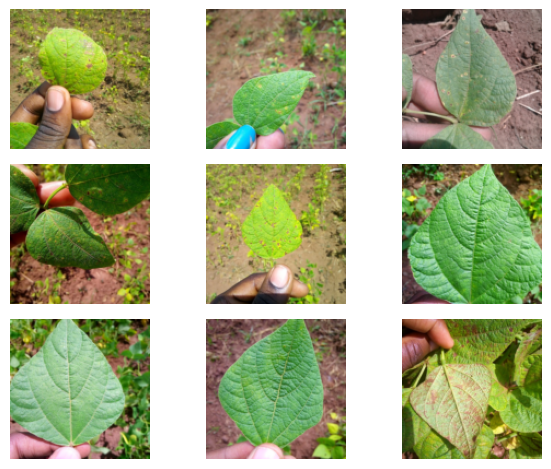

In [14]:
# =========================
# VISUALIZE RANDOM IMAGES
# =========================

n_rows = 3
# Number of rows in the grid

n_cols = 3
# Number of columns in the grid


f, axarr = plt.subplots(n_rows, n_cols)
# Creates a grid of subplots (3x3)


for row in range(n_rows):
    for col in range(n_cols):

        # Pick a random image index from training dataset
        image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
        # [0] → extracts only the image (ignores label)
        # .cpu() → ensures tensor is on CPU (matplotlib needs CPU tensors)

        # Display image
        axarr[row, col].imshow(image.permute(1, 2, 0))
        # permute(1,2,0) → converts image shape from (C, H, W) → (H, W, C)
        # Required because matplotlib expects channel-last format
        # No need for *255 → image already in [0,1] range from ToTensor()

        axarr[row, col].axis('off')
        # Removes axis ticks and labels for cleaner visualization


plt.tight_layout()
# Adjusts spacing between subplots to avoid overlap

plt.show()
# Renders the final grid of images

In [15]:
# =========================
# TRAINING HYPERPARAMETERS
# =========================

LR = 1e-3
# Learning Rate → controls how fast the model learns
# Too high → unstable training
# Too low → slow learning

BATCH_SIZE = 4
# Number of samples processed in one iteration
# Smaller batch → less memory, noisier gradients
# Larger batch → smoother gradients, needs more memory

EPOCHS = 15
# Number of times the model sees the entire dataset


# =========================
# DATALOADERS
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
# Loads training data in batches
# shuffle=True → randomizes data each epoch (prevents overfitting patterns)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
# Loads validation data in batches
# shuffle=True is optional here (usually False, since order doesn’t matter for eval)

In [16]:
# =========================
# LOAD PRETRAINED MODEL
# =========================

googlenet_model = models.googlenet(weights='DEFAULT')
# Loads pretrained GoogleNet (Inception v1) model
# weights='DEFAULT' → uses weights trained on ImageNet dataset
# This helps with transfer learning (faster + better performance)


# =========================
# UNFREEZE MODEL PARAMETERS
# =========================

for param in googlenet_model.parameters():
    param.requires_grad = True
# Enables gradient computation for all parameters
# This means the entire model will be trained (fine-tuning)

# If set to False → layer is frozen (no training)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:01<00:00, 51.1MB/s]


In [17]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [18]:
# =========================
# NUMBER OF CLASSES
# =========================

num_classes = len(train_df["category"].unique())
# Finds the number of unique classes in the dataset
# "category" column contains labels (e.g., healthy, diseased, etc.)
# unique() → returns distinct class values
# len(...) → counts total number of classes

num_classes
# Displays the number of classes (useful for verification)

3

In [21]:
googlenet_model.fc = torch.nn.Linear(
    googlenet_model.fc.in_features,
    num_classes
)
# Replaces the final fully connected (fc) layer of GoogleNet
# in_features → number of input features from previous layer (automatically taken)
# num_classes → number of output classes in your dataset
# This adapts pretrained model for your custom classification task

In [22]:
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [23]:
# =========================
# MOVE MODEL TO DEVICE
# =========================

googlenet_model = googlenet_model.to(device)
# Moves model to GPU ("cuda") if available, else CPU
# Required before training/inference

In [24]:
# =========================
# LOSS FUNCTION & OPTIMIZER
# =========================

loss_fun = nn.CrossEntropyLoss()
# CrossEntropyLoss → used for multi-class classification
# Expects raw logits (no softmax needed)

optimizer = Adam(googlenet_model.parameters(), lr=LR)
# Adam optimizer → updates model weights using gradients
# lr → learning rate (controls update step size)


# =========================
# TRAINING STORAGE (FOR PLOTS)
# =========================

total_loss_train_plot = []
# Stores loss per epoch (for visualization later)

total_acc_train_plot = []
# Stores accuracy per epoch


# =========================
# TRAINING LOOP
# =========================

for epoch in range(EPOCHS):

    total_acc_train = 0
    # Tracks correct predictions

    total_loss_train = 0
    # Tracks total loss

    for inputs, labels in train_loader:

        optimizer.zero_grad()
        # Clears old gradients (VERY IMPORTANT)

        outputs = googlenet_model(inputs)
        # Forward pass → model predictions (logits)

        train_loss = loss_fun(outputs, labels)
        # Compute loss between predictions and actual labels

        total_loss_train += train_loss.item()
        # Accumulate loss for this epoch

        train_loss.backward()
        # Backpropagation → compute gradients

        optimizer.step()
        # Update model weights

        # =========================
        # CALCULATE ACCURACY
        # =========================

        preds = torch.argmax(outputs, dim=1)
        # Gets predicted class index

        total_acc_train += (preds == labels).sum().item()
        # Counts correct predictions


    # =========================
    # STORE METRICS
    # =========================

    total_loss_train_plot.append(
        round(total_loss_train / len(train_loader), 4)
    )
    # Average loss per epoch

    total_acc_train_plot.append(
        round(total_acc_train / len(train_dataset) * 100, 4)
    )
    # Accuracy in percentage


    # =========================
    # PRINT TRAINING STATUS
    # =========================

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {total_loss_train_plot[-1]} | "
        f"Train Accuracy: {total_acc_train_plot[-1]}%"
    )

Epoch 1/15 | Train Loss: 0.7896 | Train Accuracy: 67.2147%
Epoch 2/15 | Train Loss: 0.6624 | Train Accuracy: 73.8878%
Epoch 3/15 | Train Loss: 0.5234 | Train Accuracy: 79.5938%
Epoch 4/15 | Train Loss: 0.4746 | Train Accuracy: 80.8511%
Epoch 5/15 | Train Loss: 0.4129 | Train Accuracy: 85.4932%
Epoch 6/15 | Train Loss: 0.2982 | Train Accuracy: 90.2321%
Epoch 7/15 | Train Loss: 0.2765 | Train Accuracy: 90.5222%
Epoch 8/15 | Train Loss: 0.2696 | Train Accuracy: 91.1992%
Epoch 9/15 | Train Loss: 0.2901 | Train Accuracy: 91.2959%
Epoch 10/15 | Train Loss: 0.2044 | Train Accuracy: 93.3269%
Epoch 11/15 | Train Loss: 0.1711 | Train Accuracy: 94.3907%
Epoch 12/15 | Train Loss: 0.1913 | Train Accuracy: 93.5203%
Epoch 13/15 | Train Loss: 0.1656 | Train Accuracy: 95.2611%
Epoch 14/15 | Train Loss: 0.1556 | Train Accuracy: 95.1644%
Epoch 15/15 | Train Loss: 0.2098 | Train Accuracy: 93.8104%


In [25]:
# =========================
# VALIDATION LOOP
# =========================

googlenet_model.eval()
# Sets model to evaluation mode
# Disables dropout, batchnorm updates, etc.

with torch.no_grad():
    # Disables gradient calculation → saves memory & speeds up inference

    total_loss_test = 0
    # Tracks total validation loss

    total_acc_test = 0
    # Tracks total correct predictions

    for inputs, labels in val_loader:

        outputs = googlenet_model(inputs)
        # Forward pass → predictions (logits)

        loss = loss_fun(outputs, labels)
        # Compute validation loss

        total_loss_test += loss.item()
        # Accumulate loss

        preds = torch.argmax(outputs, dim=1)
        # Get predicted class index (FIX: use dim=1, not axis)

        total_acc_test += (preds == labels).sum().item()
        # Count correct predictions


# =========================
# CALCULATE FINAL METRICS
# =========================

avg_val_loss = round(total_loss_test / len(val_loader), 4)
# Average loss across validation batches

val_accuracy = round(total_acc_test / len(val_dataset) * 100, 4)
# Accuracy in percentage

print(f"Validation Loss: {avg_val_loss} | Validation Accuracy: {val_accuracy}%")

Validation Loss: 0.2249 | Validation Accuracy: 93.985%


In [27]:
# =========================
# TRANSFER LEARNING SETUP
# =========================

googlenet_model = models.googlenet(weights='DEFAULT')
# Load pretrained GoogleNet model (trained on ImageNet)


# =========================
# FREEZE ALL LAYERS
# =========================

for param in googlenet_model.parameters():
    param.requires_grad = False
# Freezes all layers → no weight updates during training
# Model acts as a fixed feature extractor


# =========================
# MODIFY FINAL LAYER
# =========================

googlenet_model.fc = torch.nn.Linear(
    googlenet_model.fc.in_features,
    num_classes
)
# Replace final classification layer to match your dataset classes


# =========================
# TRAIN ONLY FINAL LAYER
# =========================

googlenet_model.fc.requires_grad = True
# Only the final layer will be trained
# Rest of the network remains frozen

googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [28]:
# =========================
# LOSS FUNCTION & OPTIMIZER
# =========================

loss_fun = nn.CrossEntropyLoss()
# CrossEntropyLoss → used for multi-class classification
# Takes raw logits (no softmax needed)

optimizer = Adam(googlenet_model.parameters(), lr=LR)
# Adam optimizer → updates trainable parameters
# NOTE: Only parameters with requires_grad=True will be updated


# =========================
# STORAGE FOR PLOTTING
# =========================

total_loss_train_plot = []
# Stores training loss per epoch

total_acc_train_plot = []
# Stores training accuracy per epoch


# =========================
# TRAINING LOOP
# =========================

for epoch in range(EPOCHS):

    total_acc_train = 0
    # Total correct predictions in this epoch

    total_loss_train = 0
    # Total loss in this epoch

    for inputs, labels in train_loader:

        optimizer.zero_grad()
        # Clears old gradients

        outputs = googlenet_model(inputs)
        # Forward pass → model predictions

        train_loss = loss_fun(outputs, labels)
        # Compute loss

        total_loss_train += train_loss.item()
        # Accumulate loss

        train_loss.backward()
        # Backpropagation → compute gradients

        optimizer.step()
        # Update weights

        # =========================
        # CALCULATE ACCURACY
        # =========================

        preds = torch.argmax(outputs, dim=1)
        # Get predicted class (FIX: dim=1, not axis)

        total_acc_train += (preds == labels).sum().item()
        # Count correct predictions


    # =========================
    # STORE METRICS
    # =========================

    total_loss_train_plot.append(
        round(total_loss_train / len(train_loader), 4)
    )
    # Average loss per epoch

    total_acc_train_plot.append(
        round(total_acc_train / len(train_dataset) * 100, 4)
    )
    # Accuracy in percentage


    # =========================
    # PRINT RESULTS
    # =========================

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {total_loss_train_plot[-1]} | "
        f"Train Accuracy: {total_acc_train_plot[-1]}%"
    )

Epoch 1/15 | Train Loss: 0.906 | Train Accuracy: 55.8994%
Epoch 2/15 | Train Loss: 0.7556 | Train Accuracy: 68.0851%
Epoch 3/15 | Train Loss: 0.6982 | Train Accuracy: 70.3095%
Epoch 4/15 | Train Loss: 0.6781 | Train Accuracy: 70.6963%
Epoch 5/15 | Train Loss: 0.6947 | Train Accuracy: 69.7292%
Epoch 6/15 | Train Loss: 0.6629 | Train Accuracy: 70.9865%
Epoch 7/15 | Train Loss: 0.6774 | Train Accuracy: 72.9207%
Epoch 8/15 | Train Loss: 0.6914 | Train Accuracy: 71.1799%
Epoch 9/15 | Train Loss: 0.6649 | Train Accuracy: 72.0503%
Epoch 10/15 | Train Loss: 0.722 | Train Accuracy: 68.7621%
Epoch 11/15 | Train Loss: 0.6448 | Train Accuracy: 73.1141%
Epoch 12/15 | Train Loss: 0.6001 | Train Accuracy: 76.5957%
Epoch 13/15 | Train Loss: 0.6655 | Train Accuracy: 72.9207%
Epoch 14/15 | Train Loss: 0.6587 | Train Accuracy: 72.147%
Epoch 15/15 | Train Loss: 0.6503 | Train Accuracy: 72.3404%


In [29]:
# =========================
# VALIDATION (NO GRADIENTS)
# =========================

googlenet_model.eval()
# Sets model to evaluation mode
# Disables dropout, batchnorm updates, etc.

with torch.no_grad():
    # Disables gradient computation → faster + less memory

    total_loss_test = 0
    # Tracks total validation loss

    total_acc_test = 0
    # Tracks total correct predictions

    for inputs, labels in val_loader:

        outputs = googlenet_model(inputs)
        # Forward pass → predictions (logits)

        loss = loss_fun(outputs, labels)
        # Compute validation loss

        total_loss_test += loss.item()
        # Accumulate loss

        preds = torch.argmax(outputs, dim=1)
        # Get predicted class index (FIX: use dim=1, not axis)

        total_acc_test += (preds == labels).sum().item()
        # Count correct predictions


# =========================
# FINAL METRICS
# =========================

val_loss = round(total_loss_test / len(val_loader), 4)
# Average validation loss

val_accuracy = round(total_acc_test / len(val_dataset) * 100, 2)
# Accuracy in percentage

print(f"Validation Loss: {val_loss} | Validation Accuracy: {val_accuracy}%")

Validation Loss: 0.5012 | Validation Accuracy: 78.2%
